# Практическое занятие №7 (Группа А)

## Фаза 6. Этический аудит и управление рисками

## Шаг 1. Подготовка рабочей среды и загрузка данных

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, norm
from statsmodels.stats.proportion import proportion_confint
import warnings
import re # для работы с регулярными выражениями (извлечение порога из .md)

# Настройки отображения
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Игнорирование предупреждений для чистоты вывода
warnings.filterwarnings('ignore')

print("Библиотеки успешно импортированы")


Библиотеки успешно импортированы


In [3]:
# Шаг 1.4. Загрузка данных
# Загрузка профилей компаний
profiles_df = pd.read_csv('company_profiles_for_audit.csv')
print(f"\n profiles_df: {len(profiles_df)} записей")
print(profiles_df.head(2))

# Загрузка данных о компаниях (для обогащения)
companies_df = pd.read_csv('01_crm_companies.csv')
print(f"\n companies_df: {len(companies_df)} записей")
print(companies_df.head(2))

# Загрузка прогноза
forecast_df = pd.read_csv('pro_subscription_forecast.csv')
print(f"\n forecast_df: {len(forecast_df)} записей")
print(forecast_df.head(2))

# Загрузка транзакций
transactions_df = pd.read_csv('02_crm_transactions.csv')
print(f"\n transactions_df: {len(transactions_df)} записей")
print(transactions_df.head(2))


 profiles_df: 40 записей
   company_id      company_name  readiness_score score_group_median  \
0        1001     ООО "Ромашка"            0.805         high_score   
1        1002  АО "ТехноСервис"            0.901         high_score   

  score_group_pilot  simple_readiness  is_active_lms  payment_stability  \
0        high_score                 1          1.000              1.000   
1        high_score                 1          1.000              1.000   

   norm_avg_check  avg_check  total_revenue  employee_count industry region  
0           0.350 175000.000     350000.000             120   Retail    ЦФО  
1           0.670 335000.000     670000.000              45       IT   СЗФО  

 companies_df: 40 записей
   company_id      company_name         inn industry region  employee_count  \
0        1001     ООО "Ромашка"  7701123456   Retail    ЦФО             120   
1        1002  АО "ТехноСервис"  7802123456       IT   СЗФО              45   

  created_date  status  
0   2023-0

## Шаг 2. Подготовка данных для этического аудита

In [5]:
# 2.1. Определение целевой переменной
audit_df = profiles_df.copy()
print(f"Размерность audit_df: {audit_df.shape}")
print("Первые 3 строки:")
print(audit_df.head(3))
print("\nРаспределение по score_group_pilot:")
print(audit_df['score_group_pilot'].value_counts())

Размерность audit_df: (40, 14)
Первые 3 строки:
   company_id      company_name  readiness_score score_group_median  \
0        1001     ООО "Ромашка"            0.805         high_score   
1        1002  АО "ТехноСервис"            0.901         high_score   
2        1003        ИП Сидоров            0.749         high_score   

  score_group_pilot  simple_readiness  is_active_lms  payment_stability  \
0        high_score                 1          1.000              1.000   
1        high_score                 1          1.000              1.000   
2         low_score                 1          1.000              1.000   

   norm_avg_check  avg_check  total_revenue  employee_count  industry region  
0           0.350 175000.000     350000.000             120    Retail    ЦФО  
1           0.670 335000.000     670000.000              45        IT   СЗФО  
2           0.165  82500.000     165000.000               5  Services    ЮФО  

Распределение по score_group_pilot:
score_group_p

In [6]:
# 2.2. Создание категорий размера компании
def get_size_category(emp_count):
    if pd.isna(emp_count) or emp_count <= 0:
        return 'unknown'
    elif emp_count <= 9:
        return 'micro'
    elif emp_count <= 49:
        return 'small'
    elif emp_count <= 249:
        return 'medium'
    else:
        return 'large'

audit_df['size_category'] = audit_df['employee_count'].apply(get_size_category)
print("Распределение по категориям размера:")
print(audit_df['size_category'].value_counts())

Распределение по категориям размера:
size_category
medium    15
small     13
micro      7
large      5
Name: count, dtype: int64


In [7]:
# 2.3. Расчет общей доли отобранных компаний
total_companies = len(audit_df)
high_score_count = len(audit_df[audit_df['score_group_pilot'] == 'high_score'])
overall_rate = high_score_count / total_companies * 100
print(f"Общее количество компаний: {total_companies}")
print(f"Количество отобранных (high_score): {high_score_count}")
print(f"Доля отобранных компаний: {overall_rate:.1f}%")

Общее количество компаний: 40
Количество отобранных (high_score): 12
Доля отобранных компаний: 30.0%


In [8]:
# 2.4. Определение успешных компаний (для предсказательного равенства)
analog_products = ['P002', 'P003', 'P004', 'P006']
successful_deals = transactions_df[
    (transactions_df['product_id'].isin(analog_products)) &
    (transactions_df['transaction_stage'] == 'closed_won')
]
successful_companies = set(successful_deals['company_id'].unique())
audit_df['is_successful'] = audit_df['company_id'].isin(successful_companies)

successful_count = audit_df['is_successful'].sum()
successful_rate = successful_count / total_companies * 100
successful_among_high = audit_df[audit_df['score_group_pilot'] == 'high_score']['is_successful'].sum()
successful_high_rate = successful_among_high / high_score_count * 100 if high_score_count > 0 else 0

print(f"Общее количество успешных компаний: {successful_count}")
print(f"Доля успешных среди всех компаний: {successful_rate:.1f}%")
print(f"Доля успешных среди отобранных (high_score): {successful_high_rate:.1f}%")

Общее количество успешных компаний: 28
Доля успешных среди всех компаний: 70.0%
Доля успешных среди отобранных (high_score): 83.3%


## Шаг 3. Анализ смещений (Bias Detection)

In [11]:
# Функция для расчета Cramér's V
def cramers_v(chi2, n, r, c):
    return np.sqrt(chi2 / (n * min(r-1, c-1)))
# Функция для построения столбчатой диаграммы с ДИ
def plot_rate_by_category(df, category_col, title, overall_rate):
    categories = df[category_col].value_counts().head(10).index.tolist()
    rates = []
    ci_lower = []
    ci_upper = []

    for cat in categories:
        subset = df[df[category_col] == cat]
        n = len(subset)
        k = len(subset[subset['score_group_pilot'] == 'high_score'])
        rate = k/n * 100 if n > 0 else 0
        rates.append(rate)

        if n > 0 and k > 0 and k < n:
            ci = proportion_confint(k, n, alpha=0.05, method='wilson')
            ci_lower.append(ci[0] * 100)
            ci_upper.append(ci[1] * 100)
        else:
            ci_lower.append(rate)
            ci_upper.append(rate)

    plt.figure(figsize=(12, 6))
    bars = plt.bar(categories, rates, color='steelblue', alpha=0.7)
    plt.errorbar(categories, rates, yerr=[np.array(rates)-np.array(ci_lower), np.array(ci_upper)-np.array(rates)],
                 fmt='none', color='black', capsize=5)
    plt.axhline(y=overall_rate, color='red', linestyle='--', label=f'Общая доля ({overall_rate:.1f}%)')
    plt.xlabel(category_col)
    plt.ylabel('Доля отобранных компаний (%)')
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()
    return categories, rates, ci_lower, ci_upper


Таблица сопряженности (отрасли):
score_group_pilot  high_score  low_score
industry                                
Construction                2          1
IT                          3          4
Logistics                   1          3
Retail                      2          3
Services                    0         10

Результаты:
  p-value = 0.1199
  Cramér's V = 0.5024


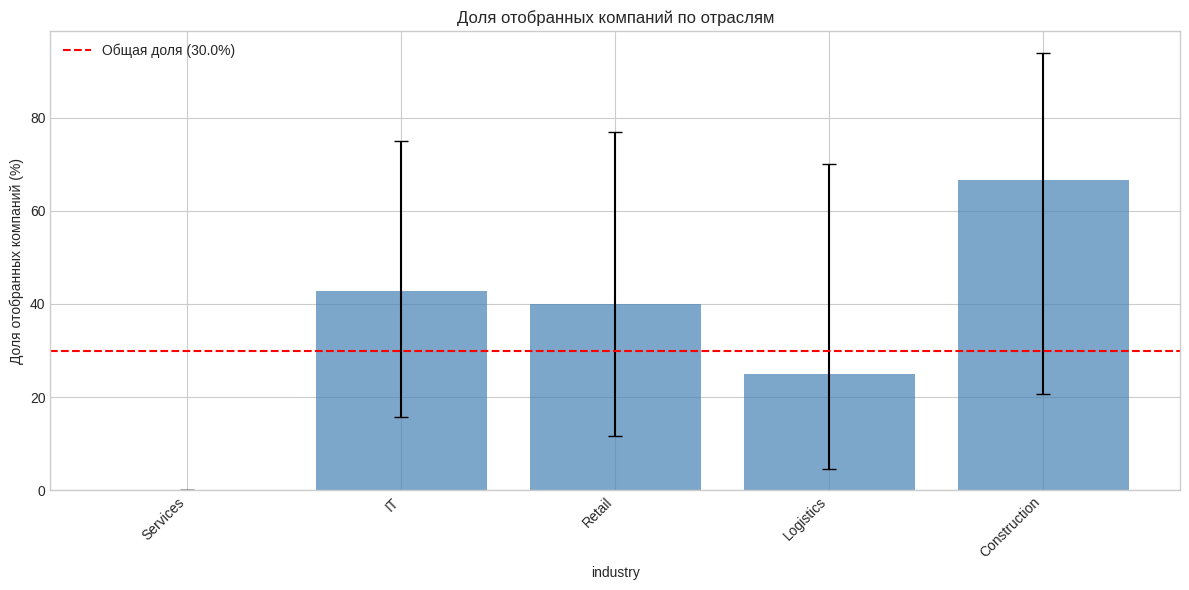

In [13]:
# 3.1. Анализ по отраслям
# Топ-5 отраслей
top_industries = audit_df['industry'].value_counts().head(5).index.tolist()
audit_industries = audit_df[audit_df['industry'].isin(top_industries)]

# Таблица сопряженности
contingency_industry = pd.crosstab(audit_industries['industry'], audit_industries['score_group_pilot'])
print("Таблица сопряженности (отрасли):")
print(contingency_industry)

# Хи-квадрат тест
chi2_industry, p_industry, dof_industry, expected_industry = chi2_contingency(contingency_industry)
v_industry = cramers_v(chi2_industry, len(audit_industries), len(contingency_industry), len(contingency_industry.columns))

print(f"\nРезультаты:")
print(f"  p-value = {p_industry:.4f}")
print(f"  Cramér's V = {v_industry:.4f}")

# График
categories, rates, ci_lower, ci_upper = plot_rate_by_category(
    audit_industries, 'industry', 'Доля отобранных компаний по отраслям', overall_rate)

Таблица сопряженности (размер):
score_group_pilot  high_score  low_score
size_category                           
large                       2          3
medium                      7          8
micro                       0          7
small                       3         10

Результаты:
  p-value = 0.1375
  Cramér's V = 0.3714


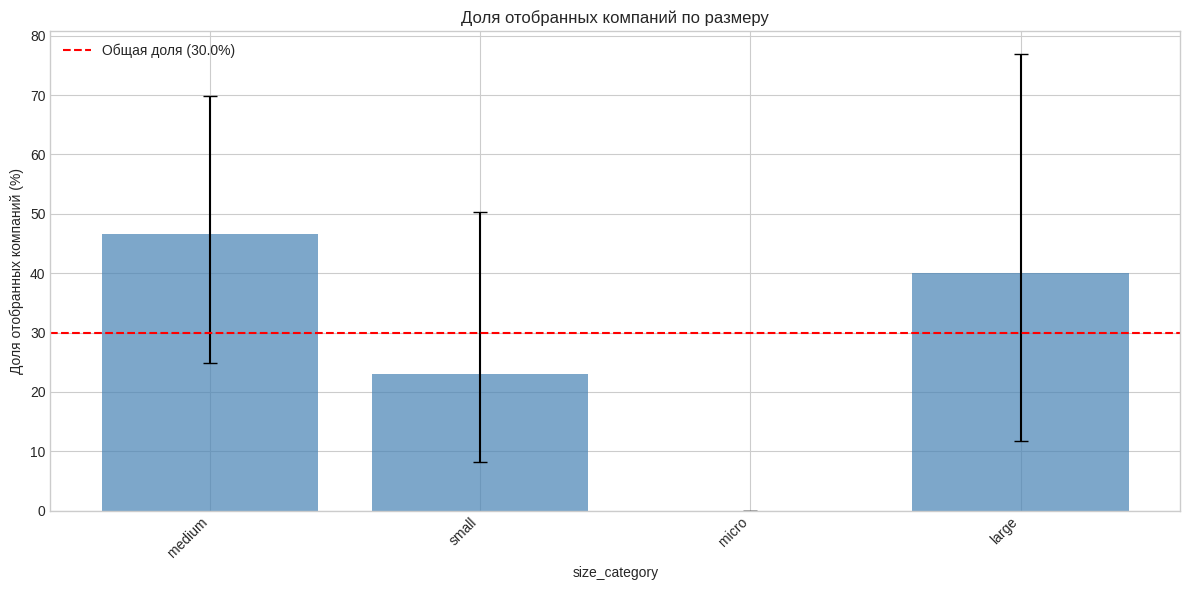

In [14]:
# 3.2. Анализ по размеру компаний

audit_size = audit_df[audit_df['size_category'] != 'unknown']
contingency_size = pd.crosstab(audit_size['size_category'], audit_size['score_group_pilot'])
print("Таблица сопряженности (размер):")
print(contingency_size)

chi2_size, p_size, dof_size, expected_size = chi2_contingency(contingency_size)
v_size = cramers_v(chi2_size, len(audit_size), len(contingency_size), len(contingency_size.columns))

print(f"\nРезультаты:")
print(f"  p-value = {p_size:.4f}")
print(f"  Cramér's V = {v_size:.4f}")

categories_size, rates_size, ci_lower_size, ci_upper_size = plot_rate_by_category(
    audit_size, 'size_category', 'Доля отобранных компаний по размеру', overall_rate)

Таблица сопряженности (регионы):
score_group_pilot  high_score  low_score
region                                  
ПФО                         3          4
СЗФО                        4          4
ЦФО                         4         11
ЮФО                         1          9

Результаты:
  p-value = 0.2552
  Cramér's V = 0.3185


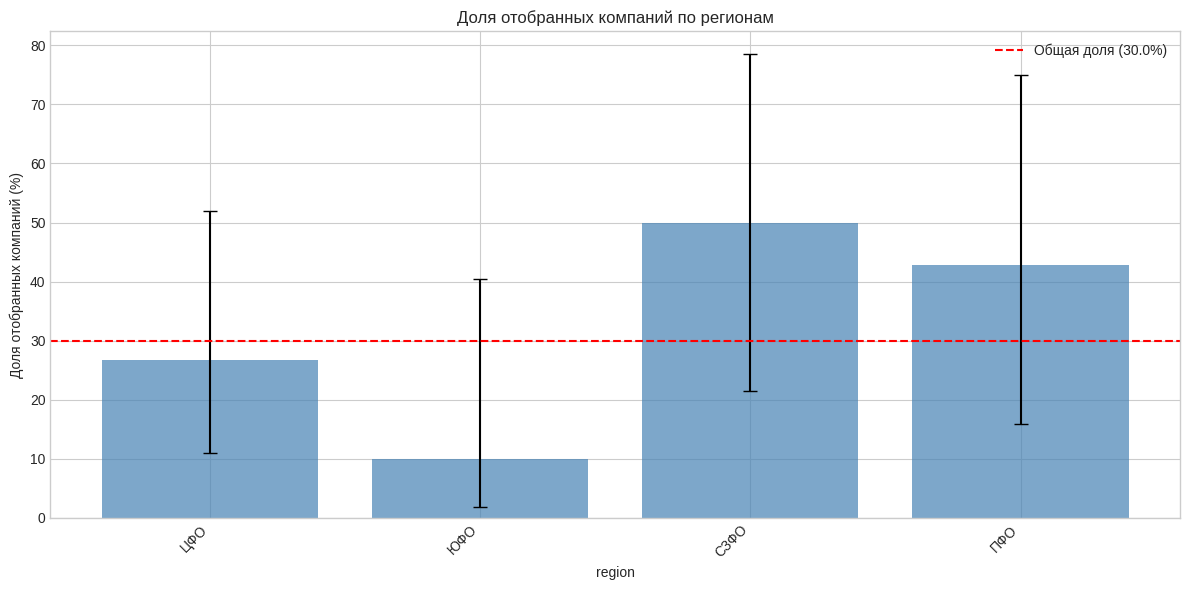

In [16]:
# 3.3. Анализ по регионам

top_regions = audit_df['region'].value_counts().head(5).index.tolist()
audit_regions = audit_df[audit_df['region'].isin(top_regions)]

contingency_region = pd.crosstab(audit_regions['region'], audit_regions['score_group_pilot'])
print("Таблица сопряженности (регионы):")
print(contingency_region)

chi2_region, p_region, dof_region, expected_region = chi2_contingency(contingency_region)
v_region = cramers_v(chi2_region, len(audit_regions), len(contingency_region), len(contingency_region.columns))

print(f"\nРезультаты:")
print(f"  p-value = {p_region:.4f}")
print(f"  Cramér's V = {v_region:.4f}")

categories_region, rates_region, ci_lower_region, ci_upper_region = plot_rate_by_category(
    audit_regions, 'region', 'Доля отобранных компаний по регионам', overall_rate)



Тепловая карта равенства возможностей:


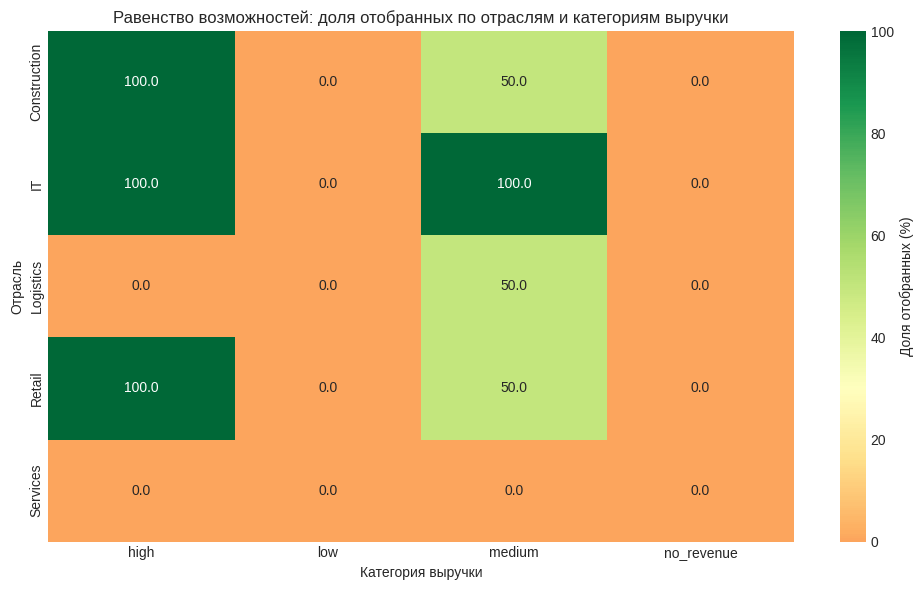

In [17]:
# 3.4. Анализ равенства возможностей (Equal Opportunity)

# Создание категорий выручки
nonzero_revenue = audit_df[audit_df['total_revenue'] > 0]['total_revenue']
q1 = nonzero_revenue.quantile(0.25)
q3 = nonzero_revenue.quantile(0.75)

def get_revenue_category(revenue):
    if revenue == 0:
        return 'no_revenue'
    elif revenue <= q1:
        return 'low'
    elif revenue <= q3:
        return 'medium'
    else:
        return 'high'

audit_df['revenue_category'] = audit_df['total_revenue'].apply(get_revenue_category)

# Сводная таблица для топ-5 отраслей
top_industries_eq = audit_df['industry'].value_counts().head(5).index.tolist()
audit_eq = audit_df[audit_df['industry'].isin(top_industries_eq)]

# Расчет долей отобранных
pivot_eq = audit_eq.pivot_table(
    index='industry',
    columns='revenue_category',
    values='score_group_pilot',
    aggfunc=lambda x: (x == 'high_score').mean() * 100,
    fill_value=0
)

print("\nТепловая карта равенства возможностей:")
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_eq, annot=True, fmt='.1f', cmap='RdYlGn', center=overall_rate,
            cbar_kws={'label': 'Доля отобранных (%)'})
plt.title('Равенство возможностей: доля отобранных по отраслям и категориям выручки')
plt.xlabel('Категория выручки')
plt.ylabel('Отрасль')
plt.tight_layout()
plt.show()


Таблица сопряженности (успешность по отраслям):
is_successful  False  True 
industry                   
Construction       1      1
Energy             0      1
Finance            0      1
IT                 0      3
Logistics          0      1
Media              0      2
Retail             1      1
p-value = 0.5697

Таблица сопряженности (успешность по размеру):
is_successful  False  True 
size_category              
large              1      1
medium             1      6
small              0      3
p-value = 0.3281

Таблица сопряженности (успешность по регионам):
is_successful  False  True 
region                     
ПФО                1      2
СЗФО               0      4
ЦФО                0      4
ЮФО                1      0
p-value = 0.0658

Общая доля успешных среди отобранных: 83.3%


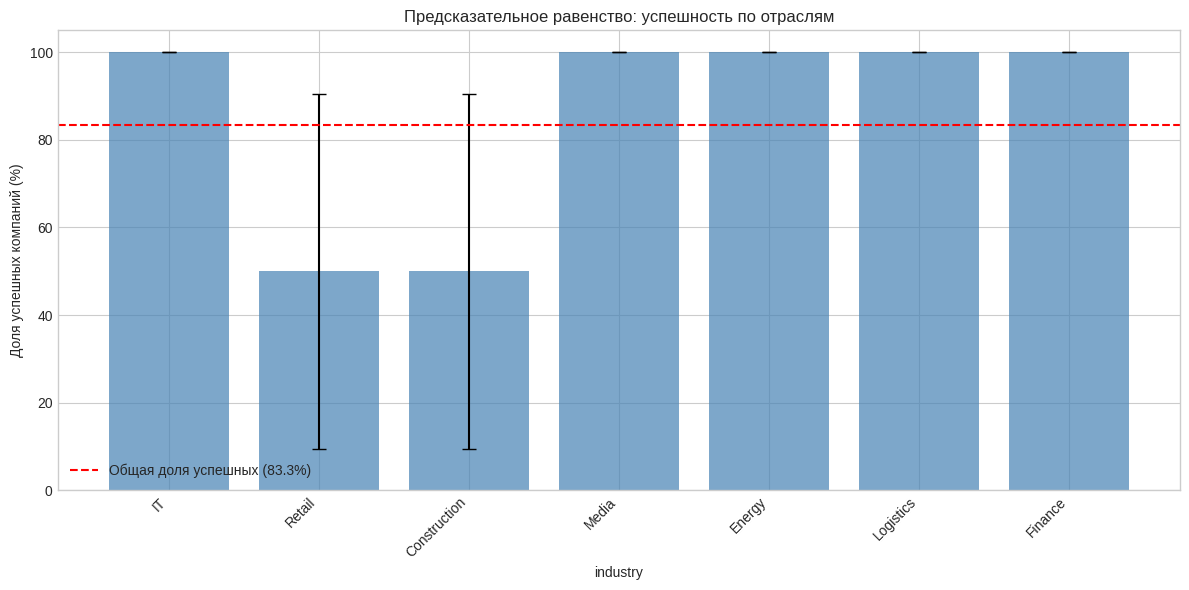

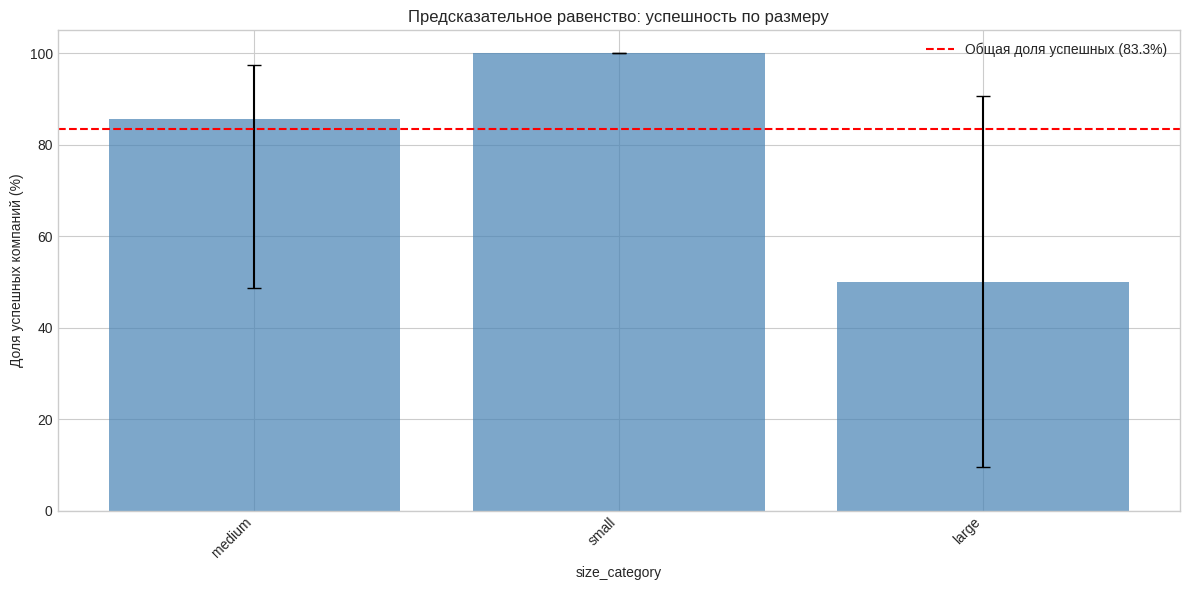

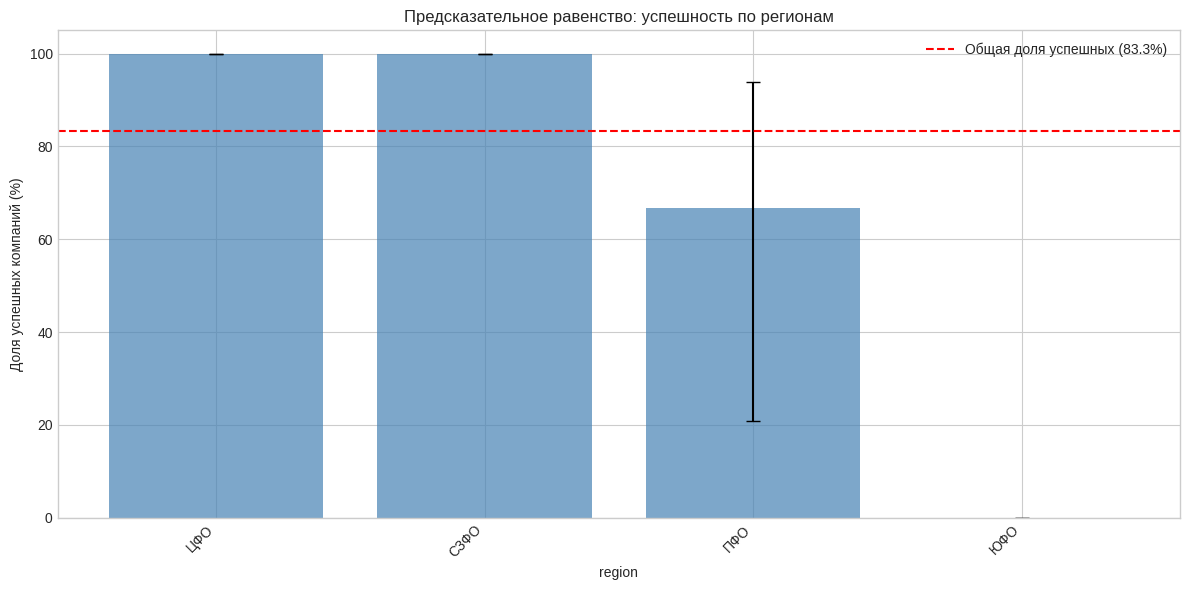

In [18]:
# 3.5. Анализ предсказательного равенства

high_score_df = audit_df[audit_df['score_group_pilot'] == 'high_score'].copy()

# По отраслям
contingency_success_industry = pd.crosstab(high_score_df['industry'], high_score_df['is_successful'])
print("\nТаблица сопряженности (успешность по отраслям):")
print(contingency_success_industry)
chi2_s_ind, p_s_ind, dof_s_ind, expected_s_ind = chi2_contingency(contingency_success_industry)
print(f"p-value = {p_s_ind:.4f}")

# По размеру
contingency_success_size = pd.crosstab(high_score_df['size_category'], high_score_df['is_successful'])
print("\nТаблица сопряженности (успешность по размеру):")
print(contingency_success_size)
chi2_s_size, p_s_size, dof_s_size, expected_s_size = chi2_contingency(contingency_success_size)
print(f"p-value = {p_s_size:.4f}")

# По регионам
contingency_success_region = pd.crosstab(high_score_df['region'], high_score_df['is_successful'])
print("\nТаблица сопряженности (успешность по регионам):")
print(contingency_success_region)
chi2_s_reg, p_s_reg, dof_s_reg, expected_s_reg = chi2_contingency(contingency_success_region)
print(f"p-value = {p_s_reg:.4f}")

# Визуализация предсказательного равенства
def plot_success_rate_by_category(df, category_col, title, overall_success_rate):
    categories = df[category_col].value_counts().head(10).index.tolist()
    rates = []
    ci_lower = []
    ci_upper = []

    for cat in categories:
        subset = df[df[category_col] == cat]
        n = len(subset)
        k = subset['is_successful'].sum()
        rate = k/n * 100 if n > 0 else 0
        rates.append(rate)

        if n > 0 and k > 0 and k < n:
            ci = proportion_confint(k, n, alpha=0.05, method='wilson')
            ci_lower.append(ci[0] * 100)
            ci_upper.append(ci[1] * 100)
        else:
            ci_lower.append(rate)
            ci_upper.append(rate)

    plt.figure(figsize=(12, 6))
    bars = plt.bar(categories, rates, color='steelblue', alpha=0.7)
    plt.errorbar(categories, rates, yerr=[np.array(rates)-np.array(ci_lower), np.array(ci_upper)-np.array(rates)],
                 fmt='none', color='black', capsize=5)
    plt.axhline(y=overall_success_rate, color='red', linestyle='--', label=f'Общая доля успешных ({overall_success_rate:.1f}%)')
    plt.xlabel(category_col)
    plt.ylabel('Доля успешных компаний (%)')
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

overall_success_rate = high_score_df['is_successful'].mean() * 100
print(f"\nОбщая доля успешных среди отобранных: {overall_success_rate:.1f}%")

plot_success_rate_by_category(high_score_df, 'industry', 'Предсказательное равенство: успешность по отраслям', overall_success_rate)
plot_success_rate_by_category(high_score_df, 'size_category', 'Предсказательное равенство: успешность по размеру', overall_success_rate)
plot_success_rate_by_category(high_score_df, 'region', 'Предсказательное равенство: успешность по регионам', overall_success_rate)

In [19]:
# 3.6. Сохранение результатов анализа смещений

bias_results = pd.DataFrame({
    'Признак': ['Отрасль', 'Размер', 'Регион'],
    'p-value (демографическое)': [p_industry, p_size, p_region],
    'Cramér\'s V': [v_industry, v_size, v_region],
    'p-value (предсказательное)': [p_s_ind, p_s_size, p_s_reg]
})
bias_results.to_csv('bias_analysis_results_A.csv', index=False)
print("bias_analysis_results_A.csv сохранен")
print(bias_results)

bias_analysis_results_A.csv сохранен
   Признак  p-value (демографическое)  Cramér's V  p-value (предсказательное)
0  Отрасль                      0.120       0.502                       0.570
1   Размер                      0.138       0.371                       0.328
2   Регион                      0.255       0.319                       0.066


## Шаг 4. Управление рисками: сценарный анализ и Монте-Карло

In [25]:
# Шаг 4.1. Загрузка прогноза из Пр-2 (исправленный)

# Ищем строку с выручкой
revenue_row = forecast_df[forecast_df['Показатель'] == 'Ожидаемая выручка (млн руб)']

if len(revenue_row) > 0:
    expected_revenue_mln = float(revenue_row['Точечный прогноз'].values[0])
    revenue_lower_mln = float(revenue_row['95% интервал нижняя'].values[0])
    revenue_upper_mln = float(revenue_row['95% интервал верхняя'].values[0])
    print(f"\n Найдены значения:")
    print(f"   Точечный прогноз выручки: {expected_revenue_mln:.2f} млн руб.")
    print(f"   Нижняя граница 95% ДИ: {revenue_lower_mln:.2f} млн руб.")
    print(f"   Верхняя граница 95% ДИ: {revenue_upper_mln:.2f} млн руб.")
else:
    print("\n Строка 'Ожидаемая выручка (млн руб)' не найдена!")
    print("   Используем значения по умолчанию:")
    expected_revenue_mln = 0.2
    revenue_lower_mln = 0.0
    revenue_upper_mln = 0.5
    print(f"   Точечный прогноз: {expected_revenue_mln} млн руб.")
    print(f"   Нижняя граница: {revenue_lower_mln} млн руб.")
    print(f"   Верхняя граница: {revenue_upper_mln} млн руб.")

cost_mln = 0.5
print(f"\nЗатраты на внедрение: {cost_mln:.2f} млн руб.")


 Найдены значения:
   Точечный прогноз выручки: 0.20 млн руб.
   Нижняя граница 95% ДИ: 0.00 млн руб.
   Верхняя граница 95% ДИ: 0.50 млн руб.

Затраты на внедрение: 0.50 млн руб.



Результаты сценарного анализа:
      Сценарий  Выручка (млн руб)  ROI (%)
Пессимистичный              0.000 -100.000
       Базовый              0.200  -60.000
 Оптимистичный              0.500    0.000

 scenario_analysis_results_A.csv сохранен


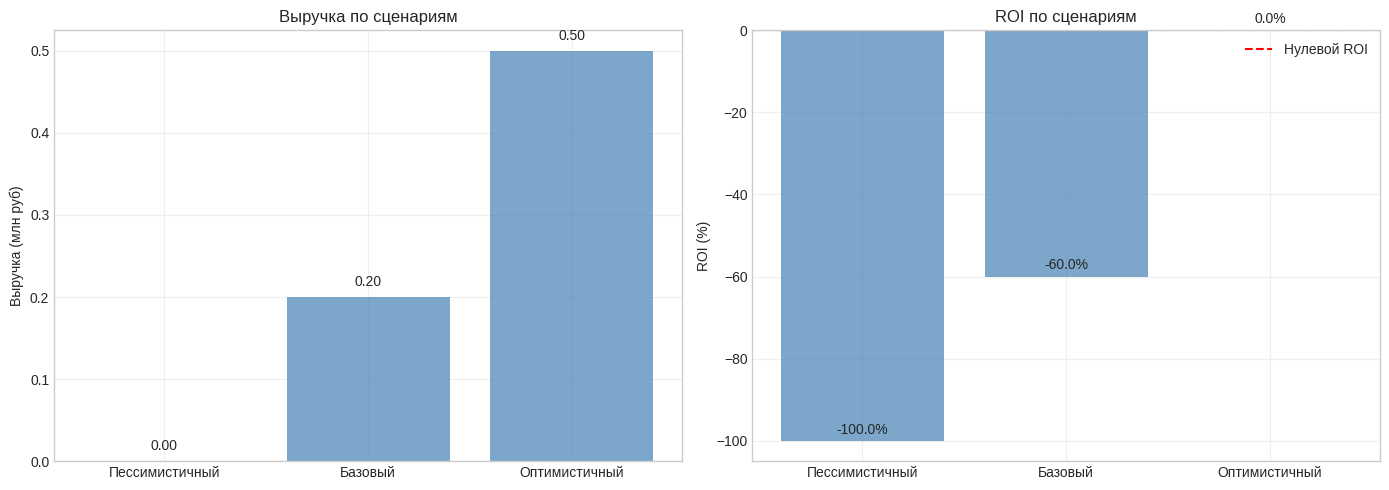

In [26]:
# 4.2. Сценарный анализ

scenarios = {
    'Пессимистичный': revenue_lower_mln,
    'Базовый': expected_revenue_mln,
    'Оптимистичный': revenue_upper_mln
}

scenario_results = []
for name, revenue in scenarios.items():
    roi = (revenue - cost_mln) / cost_mln * 100
    scenario_results.append({
        'Сценарий': name,
        'Выручка (млн руб)': revenue,
        'ROI (%)': roi
    })

scenario_df = pd.DataFrame(scenario_results)
print("\nРезультаты сценарного анализа:")
print(scenario_df.to_string(index=False))
scenario_df.to_csv('scenario_analysis_results_A.csv', index=False)
print("\n scenario_analysis_results_A.csv сохранен")

# Визуализация сценарного анализа
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(scenario_df['Сценарий'], scenario_df['Выручка (млн руб)'], color='steelblue', alpha=0.7)
for i, v in enumerate(scenario_df['Выручка (млн руб)']):
    ax1.text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom')
ax1.set_ylabel('Выручка (млн руб)')
ax1.set_title('Выручка по сценариям')
ax1.grid(True, alpha=0.3)

ax2.bar(scenario_df['Сценарий'], scenario_df['ROI (%)'], color='steelblue', alpha=0.7)
ax2.axhline(y=0, color='red', linestyle='--', label='Нулевой ROI')
for i, v in enumerate(scenario_df['ROI (%)']):
    ax2.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom')
ax2.set_ylabel('ROI (%)')
ax2.set_title('ROI по сценариям')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# 4.3. Монте-Карло симуляция

# Оценка стандартного отклонения
sigma_mln = (revenue_upper_mln - revenue_lower_mln) / (2 * 1.96)
print(f"Стандартное отклонение выручки: {sigma_mln:.4f} млн руб.")

n_simulations = 10000
np.random.seed(123)

revenues_sim = np.random.normal(expected_revenue_mln, sigma_mln, n_simulations)
revenues_sim = np.maximum(revenues_sim, 0)
roi_sim = (revenues_sim - cost_mln) / cost_mln * 100

print(f"\nРезультаты Монте-Карло симуляции ({n_simulations} итераций):")
print(f"  Средний ROI: {roi_sim.mean():.2f}%")
print(f"  Медианный ROI: {np.median(roi_sim):.2f}%")
print(f"  Стандартное отклонение ROI: {roi_sim.std():.2f}%")
print(f"  95% доверительный интервал ROI: [{np.percentile(roi_sim, 2.5):.2f}%, {np.percentile(roi_sim, 97.5):.2f}%]")
print(f"  Вероятность убыточности (ROI ≤ 0): {(roi_sim <= 0).mean()*100:.2f}%")
print(f"  Вероятность ROI > 20%: {(roi_sim > 20).mean()*100:.2f}%")

# Сохранение результатов симуляции
monte_carlo_df = pd.DataFrame({'roi': roi_sim, 'revenue_mln': revenues_sim})
monte_carlo_df.to_csv('monte_carlo_results_A.csv', index=False)
print("\n monte_carlo_results_A.csv сохранен")

Стандартное отклонение выручки: 0.1276 млн руб.

Результаты Монте-Карло симуляции (10000 итераций):
  Средний ROI: -59.16%
  Медианный ROI: -59.70%
  Стандартное отклонение ROI: 24.27%
  95% доверительный интервал ROI: [-100.00%, -10.02%]
  Вероятность убыточности (ROI ≤ 0): 99.09%
  Вероятность ROI > 20%: 0.07%

 monte_carlo_results_A.csv сохранен


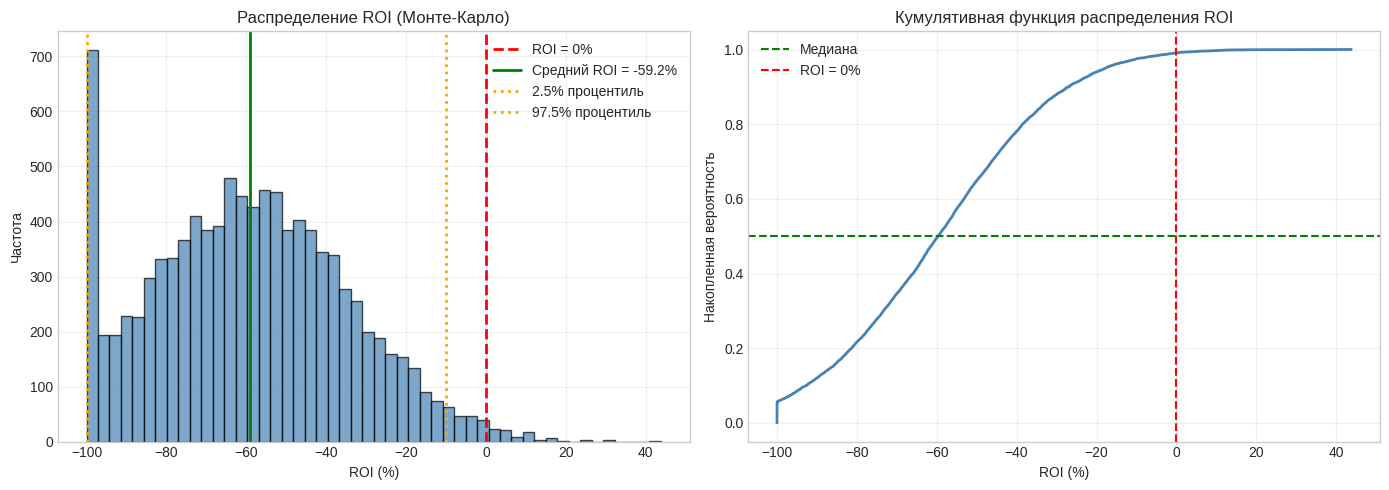

In [28]:
# Визуализация Монте-Карло
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(roi_sim, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='ROI = 0%')
ax1.axvline(x=roi_sim.mean(), color='green', linestyle='-', linewidth=2, label=f'Средний ROI = {roi_sim.mean():.1f}%')
ax1.axvline(x=np.percentile(roi_sim, 2.5), color='orange', linestyle=':', linewidth=2, label='2.5% процентиль')
ax1.axvline(x=np.percentile(roi_sim, 97.5), color='orange', linestyle=':', linewidth=2, label='97.5% процентиль')
ax1.set_xlabel('ROI (%)')
ax1.set_ylabel('Частота')
ax1.set_title('Распределение ROI (Монте-Карло)')
ax1.legend()
ax1.grid(True, alpha=0.3)

sorted_roi = np.sort(roi_sim)
cdf = np.arange(1, len(sorted_roi) + 1) / len(sorted_roi)
ax2.plot(sorted_roi, cdf, linewidth=2, color='steelblue')
ax2.axhline(y=0.5, color='green', linestyle='--', linewidth=1.5, label='Медиана')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='ROI = 0%')
ax2.set_xlabel('ROI (%)')
ax2.set_ylabel('Накопленная вероятность')
ax2.set_title('Кумулятивная функция распределения ROI')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# 4.4. Интерпретация результатов

base_roi = scenario_df[scenario_df['Сценарий'] == 'Базовый']['ROI (%)'].values[0]
pessimistic_roi = scenario_df[scenario_df['Сценарий'] == 'Пессимистичный']['ROI (%)'].values[0]
optimistic_roi = scenario_df[scenario_df['Сценарий'] == 'Оптимистичный']['ROI (%)'].values[0]

print(f"\n1. При базовом сценарии окупаемость затрат (ROI) составит {base_roi:.1f}%.")
print(f"\n2. В пессимистичном сценарии (нижняя граница ДИ) ROI = {pessimistic_roi:.1f}%.")
print(f"\n3. В оптимистичном сценарии (верхняя граница ДИ) ROI = {optimistic_roi:.1f}%.")
print(f"\n4. По результатам Монте-Карло симуляции:")
print(f"   - Вероятность того, что проект окажется убыточным (ROI < 0): {(roi_sim <= 0).mean()*100:.1f}%")
print(f"   - Вероятность достижения ROI > 20%: {(roi_sim > 20).mean()*100:.1f}%")
print(f"   - 95% доверительный интервал ROI: от {np.percentile(roi_sim, 2.5):.1f}% до {np.percentile(roi_sim, 97.5):.1f}%")


1. При базовом сценарии окупаемость затрат (ROI) составит -60.0%.

2. В пессимистичном сценарии (нижняя граница ДИ) ROI = -100.0%.

3. В оптимистичном сценарии (верхняя граница ДИ) ROI = 0.0%.

4. По результатам Монте-Карло симуляции:
   - Вероятность того, что проект окажется убыточным (ROI < 0): 99.1%
   - Вероятность достижения ROI > 20%: 0.1%
   - 95% доверительный интервал ROI: от -100.0% до -10.0%
